In [1]:
!cd ~/c/iu9-sql-compiler/ && ./build-release/bin/benchmarks --benchmark_filter='^OperatorCost/' --benchmark_out=/tmp/operator-cost.json --benchmark_out_format=json

2026-06-09T23:39:57+03:00
Running ./build-release/bin/benchmarks
Run on (8 X 4200 MHz CPU s)
CPU Caches:
  L1 Data 48 KiB (x4)
  L1 Instruction 32 KiB (x4)
  L2 Unified 1280 KiB (x4)
  L3 Unified 8192 KiB (x1)
Load Average: 0.33, 0.62, 1.01
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
---------------------------------------------------------------------------------------------------------------
Benchmark                                                     Time             CPU   Iterations UserCounters...
---------------------------------------------------------------------------------------------------------------
OperatorCost/SeqScan/1024/real_time                       37629 ns        37491 ns        18331 model_cost=102.4k output_rows=1.024k plan_cost=102.4k rows=1.024k
OperatorCost/SeqScan/2048/real_time                       72904 ns        72542 ns        10020 model_cost=204.8k output_rows=2.048k plan_cost

In [2]:
!ls -l /tmp | grep operator-cost

-rw-r--r--  1 st     users    40322 Jun  9 23:41 operator-cost.json
-rw-r--r--  1 st     users    33223 May 31 16:03 operator-cost-matched-calibrated-smoke.json
-rw-r--r--  1 st     users    33305 May 31 16:16 operator-cost-matched.json
-rw-r--r--  1 st     users     6149 May 31 15:08 operator-cost-matched-plan-cost-smoke.json
-rw-r--r--  1 st     users     2010 May 30 19:02 operator-cost-smoke.json


In [3]:
import json

results = None
with open('/tmp/operator-cost.json') as f:
    results = json.load(f)

results

{'context': {'date': '2026-06-09T23:39:57+03:00',
  'host_name': 'nixos',
  'executable': './build-release/bin/benchmarks',
  'num_cpus': 8,
  'mhz_per_cpu': 4200,
  'cpu_scaling_enabled': True,
  'caches': [{'type': 'Data', 'level': 1, 'size': 49152, 'num_sharing': 2},
   {'type': 'Instruction', 'level': 1, 'size': 32768, 'num_sharing': 2},
   {'type': 'Unified', 'level': 2, 'size': 1310720, 'num_sharing': 2},
   {'type': 'Unified', 'level': 3, 'size': 8388608, 'num_sharing': 8}],
  'load_avg': [0.331543, 0.623535, 1.01465],
  'library_version': 'v1.9.0',
  'library_build_type': 'release',
  'json_schema_version': 1},
 'benchmarks': [{'name': 'OperatorCost/SeqScan/1024/real_time',
   'family_index': 0,
   'per_family_instance_index': 0,
   'run_name': 'OperatorCost/SeqScan/1024/real_time',
   'run_type': 'iteration',
   'repetitions': 1,
   'repetition_index': 0,
   'threads': 1,
   'iterations': 18331,
   'real_time': 37628.93579271746,
   'cpu_time': 37491.17609513937,
   'time_unit

In [4]:
import pandas as pd

assert results

df = pd.DataFrame(results['benchmarks'])
df = df[df['run_type'] == 'iteration'].copy()

parts = df['name'].str.split('/')
df['operator'] = parts.str[1]
df['left_rows'] = parts.str[2].astype(int)
df['right_rows'] = parts.apply(lambda p: int(p[3]) if len(p) == 5 else None)

df['real_time_ms'] = df['real_time'] / 1e6

df[['operator', 'left_rows', 'right_rows', 'real_time_ms', 'model_cost']].sort_values(['operator', 'left_rows'])

,operator,left_rows,right_rows,real_time_ms,model_cost
36,Aggregation,1024,NaN,0.279850,522240.0
37,Aggregation,2048,NaN,0.547978,1044480.0
38,Aggregation,4096,NaN,1.112645,2088960.0
39,Aggregation,8192,NaN,2.393267,4177920.0
40,Aggregation,16384,NaN,6.024309,8355840.0
...,...,...,...,...,...
31,Sort,16384,NaN,3.425096,2703360.0
32,Sort,32768,NaN,8.128588,5767168.0
33,Sort,65536,NaN,21.036047,12255232.0
34,Sort,131072,NaN,68.694607,25952256.0


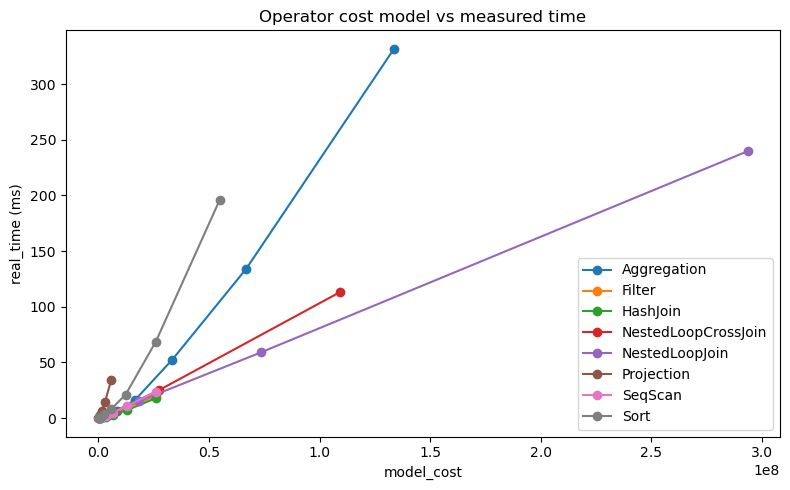

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for op, grp in df.groupby('operator'):
    ax.plot(grp['model_cost'], grp['real_time_ms'], marker='o', label=op)

ax.set_xlabel('model_cost')
ax.set_ylabel('real_time (ms)')
ax.set_title('Operator cost model vs measured time')
ax.legend()
plt.tight_layout()
plt.show()

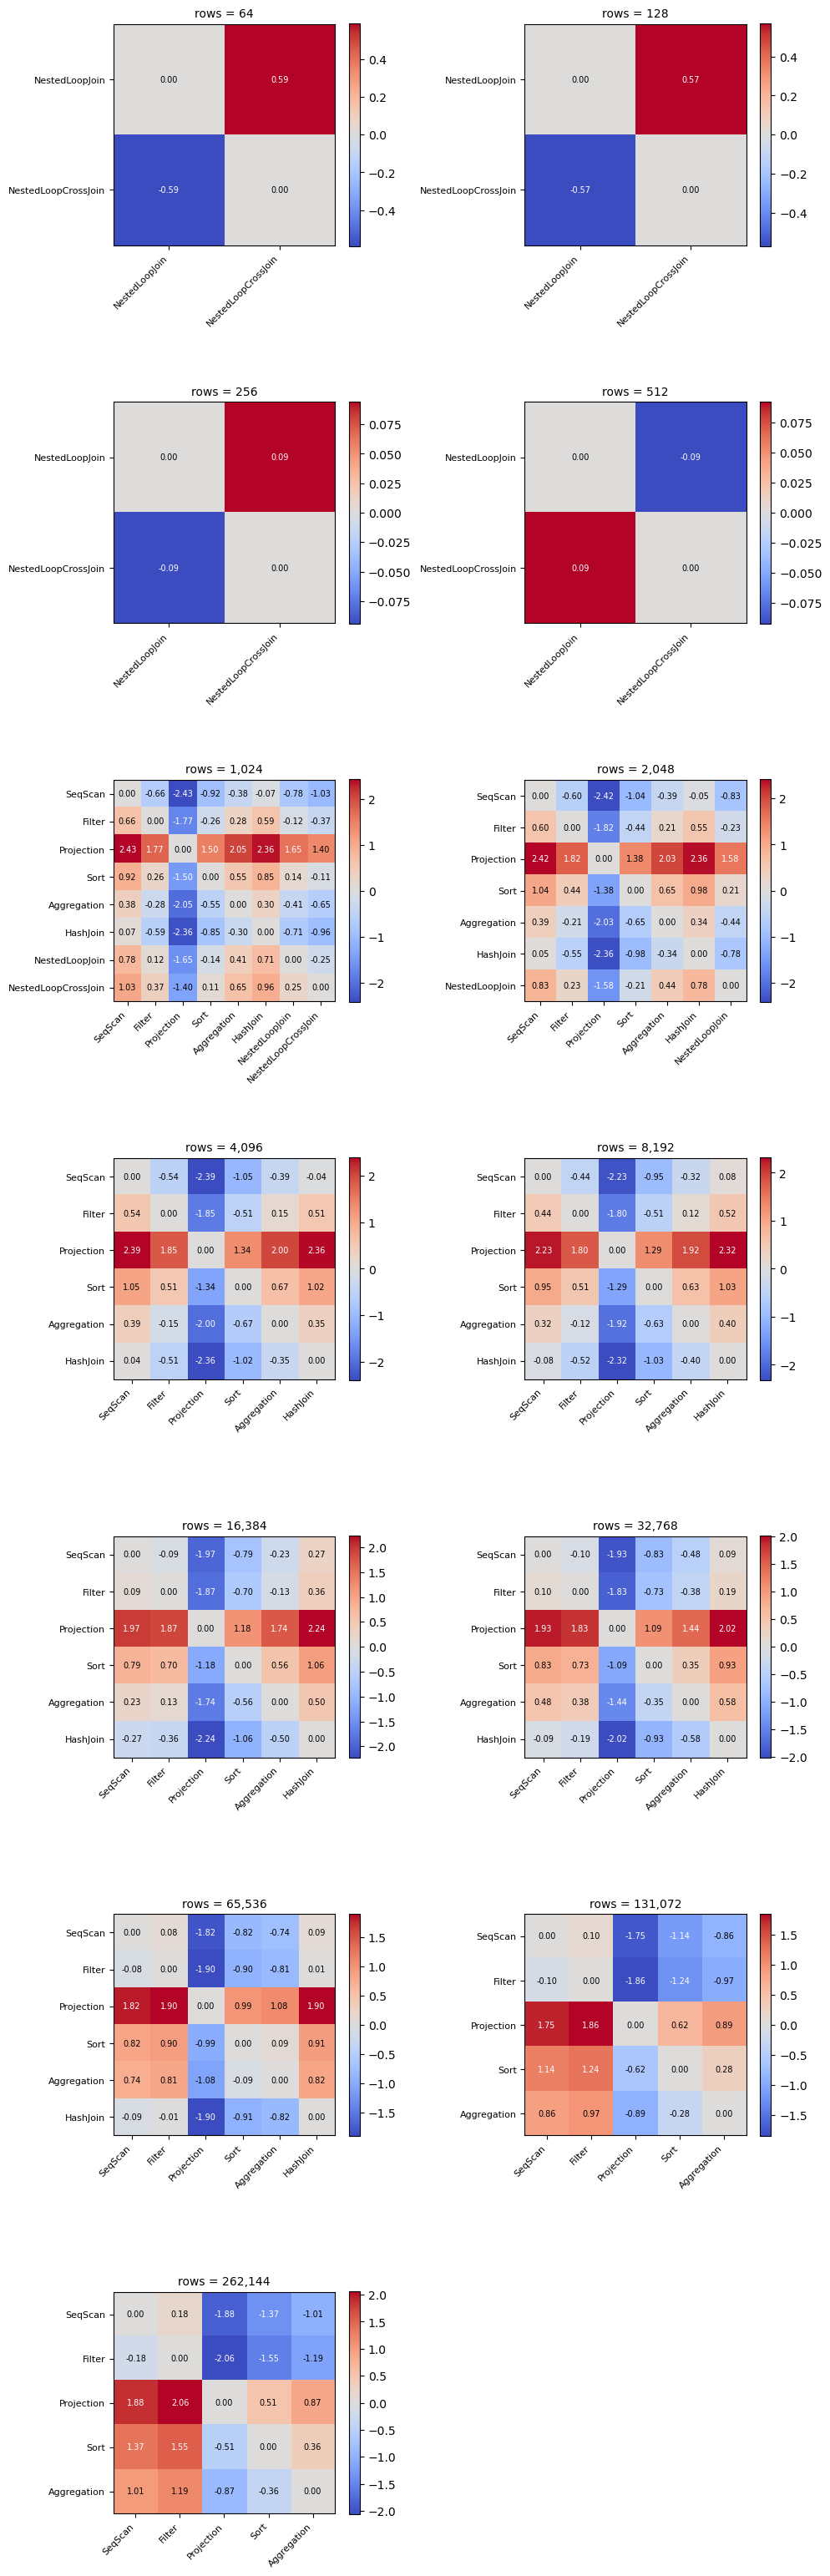

In [6]:
import matplotlib.pyplot as plt
import numpy as np

pivot = df.set_index(['operator', 'left_rows'])[['cpu_time', 'model_cost']]

all_counts = sorted(df['left_rows'].unique())
valid_counts = [rc for rc in all_counts
                if pivot.index.get_level_values('left_rows').isin([rc]).sum() >= 2]

ncols = 2
nrows = (len(valid_counts) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

for idx, rc in enumerate(valid_counts):
    ax = axes[idx // ncols][idx % ncols]
    sub = pivot.xs(rc, level='left_rows')
    ops = sub.index.tolist()
    m = len(ops)

    mat = np.zeros((m, m))
    for i, a in enumerate(ops):
        for j, b in enumerate(ops):
            if i != j:
                mat[i, j] = (np.log(sub.loc[a, 'cpu_time'])   - np.log(sub.loc[b, 'cpu_time']) -
                             (np.log(sub.loc[a, 'model_cost']) - np.log(sub.loc[b, 'model_cost'])))

    vmax = np.abs(mat).max() or 1.0
    im = ax.imshow(mat, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(m)); ax.set_xticklabels(ops, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(m)); ax.set_yticklabels(ops, fontsize=8)
    ax.set_title(f'rows = {rc:,}', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(m):
        for j in range(m):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if abs(mat[i,j]) < vmax * 0.6 else 'white')

for idx in range(len(valid_counts), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
rows = []
for rc in valid_counts:
    sub = pivot.xs(rc, level='left_rows')
    ops = sub.index.tolist()
    for a in ops:
        for b in ops:
            if a != b:
                delta = (np.log(sub.loc[a, 'cpu_time'])   - np.log(sub.loc[b, 'cpu_time']) -
                        (np.log(sub.loc[a, 'model_cost']) - np.log(sub.loc[b, 'model_cost'])))
                rows.append({'row_count': rc, 'a': a, 'b': b, 'delta': delta})

comparison = pd.DataFrame(rows)
comparison.pivot_table(index=['a', 'b'], columns='row_count', values='delta').round(3)

row_count                                64      128     256     512     \
a                   b                                                     
Aggregation         Filter                  NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin     NaN     NaN     NaN     NaN   
                    NestedLoopJoin          NaN     NaN     NaN     NaN   
                    Projection              NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
Filter              Aggregation             NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin     NaN     NaN     NaN     NaN   
                    NestedLoopJoin          NaN     NaN     NaN     NaN   
                    Projection              NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
HashJoin            Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin     NaN     NaN     NaN     NaN   
                    NestedLoopJoin          NaN     NaN     NaN     NaN   
                    Projection              NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
NestedLoopCrossJoin Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopJoin        -0.59   -0.57  -0.094   0.093   
                    Projection              NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
NestedLoopJoin      Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin    0.59    0.57   0.094  -0.093   
                    Projection              NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
Projection          Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin     NaN     NaN     NaN     NaN   
                    NestedLoopJoin          NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
SeqScan             Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin     NaN     NaN     NaN     NaN   
                    NestedLoopJoin          NaN     NaN     NaN     NaN   
                    Projection              NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
Sort                Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    HashJ

In [8]:
!cd ~/c/iu9-sql-compiler/ && ./build-release/bin/benchmarks --benchmark_filter='OperatorCostMatched*' --benchmark_out=/tmp/operator-cost-matched.json --benchmark_out_format=json

2026-06-09T23:41:04+03:00
Running ./build-release/bin/benchmarks
Run on (8 X 4200 MHz CPU s)
CPU Caches:
  L1 Data 48 KiB (x4)
  L1 Instruction 32 KiB (x4)
  L2 Unified 1280 KiB (x4)
  L3 Unified 8192 KiB (x1)
Load Average: 1.09, 0.80, 1.04
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
-----------------------------------------------------------------------------------------------------------------------------------------
Benchmark                                                                               Time             CPU   Iterations UserCounters...
-----------------------------------------------------------------------------------------------------------------------------------------
OperatorCostMatched/target_cost:640000/SeqScan/6400/real_time                      309954 ns       306993 ns         2231 model_cost=640k output_rows=6.4k plan_cost=640k rows=6.4k
OperatorCostMatched/target_cost:640000/Filter/

In [9]:
import json
results = None
with open('/tmp/operator-cost-matched.json') as f:
    results = json.load(f)

results

{'context': {'date': '2026-06-09T23:41:04+03:00',
  'host_name': 'nixos',
  'executable': './build-release/bin/benchmarks',
  'num_cpus': 8,
  'mhz_per_cpu': 4200,
  'cpu_scaling_enabled': True,
  'caches': [{'type': 'Data', 'level': 1, 'size': 49152, 'num_sharing': 2},
   {'type': 'Instruction', 'level': 1, 'size': 32768, 'num_sharing': 2},
   {'type': 'Unified', 'level': 2, 'size': 1310720, 'num_sharing': 2},
   {'type': 'Unified', 'level': 3, 'size': 8388608, 'num_sharing': 8}],
  'load_avg': [1.09375, 0.795898, 1.04199],
  'library_version': 'v1.9.0',
  'library_build_type': 'release',
  'json_schema_version': 1},
 'benchmarks': [{'name': 'OperatorCostMatched/target_cost:640000/SeqScan/6400/real_time',
   'family_index': 0,
   'per_family_instance_index': 0,
   'run_name': 'OperatorCostMatched/target_cost:640000/SeqScan/6400/real_time',
   'run_type': 'iteration',
   'repetitions': 1,
   'repetition_index': 0,
   'threads': 1,
   'iterations': 2231,
   'real_time': 309954.099962947

In [10]:
matched_df = pd.DataFrame(results['benchmarks'])
matched_df = matched_df[matched_df['run_type'] == 'iteration'].copy()

parts = matched_df['name'].str.split('/')
matched_df['target_cost'] = parts.str[1].str.removeprefix('target_cost:').astype(int)
matched_df['operator'] = parts.str[2]
matched_df['left_rows'] = parts.str[3].astype(int)
matched_df['right_rows'] = parts.apply(lambda p: int(p[4]) if len(p) == 6 else None)
matched_df['real_time_ms'] = matched_df['real_time'] / 1e6

matched_df['matching_error'] = (matched_df['model_cost'] - matched_df['target_cost']).abs() / matched_df['target_cost']
assert (matched_df['matching_error'] < 0.02).all()

matched_df[['target_cost', 'operator', 'left_rows', 'right_rows', 'real_time_ms', 'model_cost', 'plan_cost', 'matching_error']].sort_values(['target_cost', 'operator'])

,target_cost,operator,left_rows,right_rows,real_time_ms,model_cost,plan_cost,matching_error
4,640000,Aggregation,1255,NaN,0.348253,640050.0,765550.0,7.812500e-05
1,640000,Filter,6400,NaN,0.407352,640000.0,1280000.0,0.000000e+00
5,640000,HashJoin,1620,1620.0,0.246864,639900.0,963900.0,1.562500e-04
7,640000,NestedLoopCrossJoin,78,78.0,0.399168,632736.0,648336.0,1.135000e-02
6,640000,NestedLoopJoin,96,96.0,0.697766,645120.0,664320.0,8.000000e-03
2,640000,Projection,29091,NaN,3.320695,640002.0,3549102.0,3.125000e-06
0,640000,SeqScan,6400,NaN,0.309954,640000.0,640000.0,0.000000e+00
3,640000,Sort,4476,NaN,0.720259,640068.0,1087668.0,1.062500e-04
12,1000000,Aggregation,1961,NaN,0.531581,1000110.0,1196210.0,1.100000e-04
9,1000000,Filter,10000,NaN,0.657861,1000000.0,2000000.0,0.000000e+00


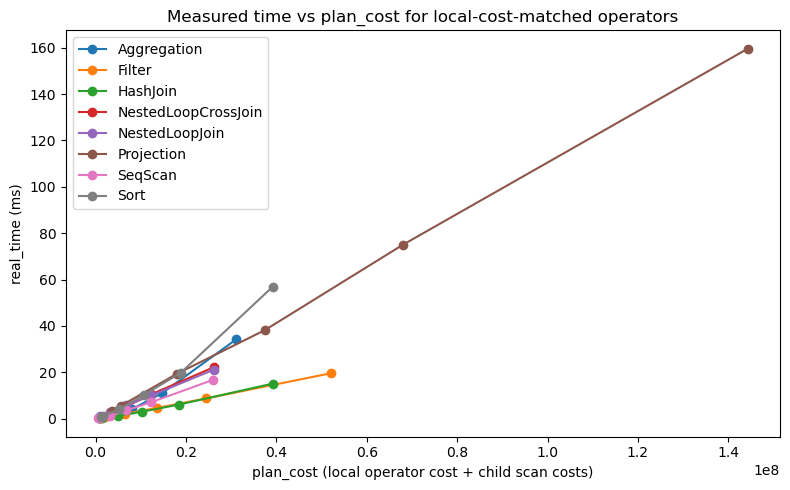

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
for op, grp in matched_df.groupby('operator'):
    grp = grp.sort_values('plan_cost')
    ax.plot(grp['plan_cost'], grp['real_time_ms'], marker='o', label=op)

ax.set_xlabel('plan_cost (local operator cost + child scan costs)')
ax.set_ylabel('real_time (ms)')
ax.set_title('Measured time vs plan_cost for local-cost-matched operators')
ax.legend()
plt.tight_layout()
plt.show()

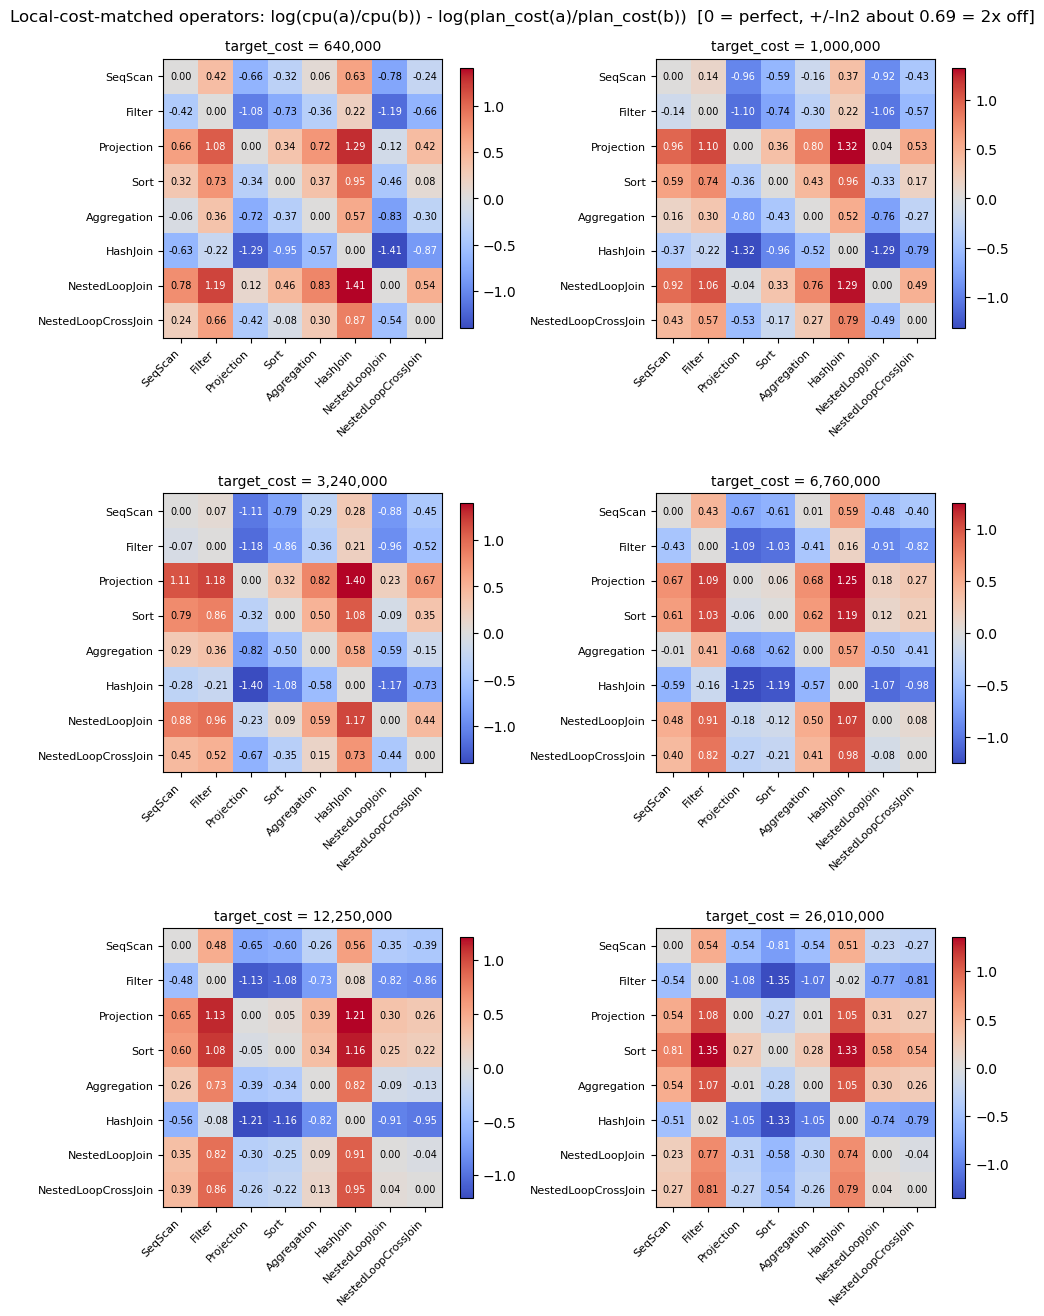

In [12]:
matched_pivot = matched_df.set_index(['target_cost', 'operator'])[['cpu_time', 'model_cost', 'plan_cost']]
matched_costs = sorted(matched_df['target_cost'].unique())

ncols = 2
nrows = (len(matched_costs) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

for idx, target_cost in enumerate(matched_costs):
    ax = axes[idx // ncols][idx % ncols]
    sub = matched_pivot.xs(target_cost, level='target_cost')
    ops = sub.index.tolist()
    m = len(ops)

    mat = np.zeros((m, m))
    for i, a in enumerate(ops):
        for j, b in enumerate(ops):
            if i != j:
                mat[i, j] = (np.log(sub.loc[a, 'cpu_time']) - np.log(sub.loc[b, 'cpu_time']) -
                             (np.log(sub.loc[a, 'plan_cost']) - np.log(sub.loc[b, 'plan_cost'])))

    vmax = np.abs(mat).max() or 1.0
    im = ax.imshow(mat, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(m)); ax.set_xticklabels(ops, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(m)); ax.set_yticklabels(ops, fontsize=8)
    ax.set_title(f'target_cost = {target_cost:,}', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(m):
        for j in range(m):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if abs(mat[i,j]) < vmax * 0.6 else 'white')

for idx in range(len(matched_costs), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle('Local-cost-matched operators: log(cpu(a)/cpu(b)) - log(plan_cost(a)/plan_cost(b))  [0 = perfect, +/-ln2 about 0.69 = 2x off]', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
matched_rows = []
for target_cost in matched_costs:
    sub = matched_pivot.xs(target_cost, level='target_cost')
    ops = sub.index.tolist()
    for a in ops:
        for b in ops:
            if a != b:
                delta = (np.log(sub.loc[a, 'cpu_time']) - np.log(sub.loc[b, 'cpu_time']) -
                         (np.log(sub.loc[a, 'plan_cost']) - np.log(sub.loc[b, 'plan_cost'])))
                matched_rows.append({'target_cost': target_cost, 'a': a, 'b': b, 'delta': delta})

matched_comparison = pd.DataFrame(matched_rows)
matched_comparison.pivot_table(index=['a', 'b'], columns='target_cost', values='delta').round(3)

target_cost                              640000    1000000   3240000   \
a                   b                                                   
Aggregation         Filter                  0.359     0.302     0.364   
                    HashJoin                0.575     0.525     0.577   
                    NestedLoopCrossJoin    -0.297    -0.267    -0.153   
                    NestedLoopJoin         -0.834    -0.762    -0.592   
                    Projection             -0.717    -0.798    -0.820   
                    SeqScan                -0.056     0.159     0.292   
                    Sort                   -0.374    -0.434    -0.498   
Filter              Aggregation            -0.359    -0.302    -0.364   
                    HashJoin                0.216     0.223     0.213   
                    NestedLoopCrossJoin    -0.656    -0.569    -0.517   
                    NestedLoopJoin         -1.193    -1.063    -0.956   
                    Projection             -1.076    -1.099    -1.184   
                    SeqScan                -0.416    -0.143    -0.071   
                    Sort                   -0.733    -0.735    -0.862   
HashJoin            Aggregation            -0.575    -0.525    -0.577   
                    Filter                 -0.216    -0.223    -0.213   
                    NestedLoopCrossJoin    -0.872    -0.792    -0.730   
                    NestedLoopJoin         -1.409    -1.287    -1.169   
                    Projection             -1.291    -1.322    -1.397   
                    SeqScan                -0.631    -0.366    -0.285   
                    Sort                   -0.949    -0.958    -1.075   
NestedLoopCrossJoin Aggregation             0.297     0.267     0.153   
                    Filter                  0.656     0.569     0.517   
                    HashJoin                0.872     0.792     0.730   
                    NestedLoopJoin         -0.537    -0.495    -0.439   
                    Projection             -0.420    -0.531    -0.667   
                    SeqScan                 0.241     0.426     0.445   
                    Sort                   -0.077    -0.167    -0.345   
NestedLoopJoin      Aggregation             0.834     0.762     0.592   
                    Filter                  1.193     1.063     0.956   
                    HashJoin                1.409     1.287     1.169   
                    NestedLoopCrossJoin     0.537     0.495     0.439   
                    Projection              0.118    -0.036    -0.228   
                    SeqScan                 0.778     0.921     0.884   
                    Sort                    0.460     0.328     0.094   
Projection          Aggregation             0.717     0.798     0.820   
                    Filter                  1.076     1.099     1.184   
                    HashJoin                1.291     1.322     1.397   
                    NestedLoopCrossJoin     0.420     0.531     0.667   
                    NestedLoopJoin         -0.118     0.036     0.228   
                    SeqScan                 0.660     0.956     1.113   
                    Sort                    0.343     0.364     0.322   
SeqScan             Aggregation             0.056    -0.159    -0.292   
                    Filter                  0.416     0.143     0.071   
                    HashJoin                0.631     0.366     0.285   
                    NestedLoopCrossJoin    -0.241    -0.426    -0.445   
                    NestedLoopJoin         -0.778    -0.921    -0.884   
                    Projection             -0.660    -0.956    -1.113   
                    Sort                   -0.318    -0.593    -0.791   
Sort                Aggregation             0.374     0.434     0.498   
                    Filter                  0.733     0.735     0.862   
                    HashJoin                0.949     0.958     1.075   
                    NestedLoopCrossJoin     0.077     0.16